### Q1: VANILLA DQN IMPLEMENTATION

In [40]:
import gymnasium as gym
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [41]:
ENV_NAME = "MountainCar-v0"

def make_env(seed):
    env = gym.make(ENV_NAME)
    env.reset(seed=seed)

    # Override max episode steps to 2000 (IMPORTANT)
    env._max_episode_steps = 2000

    return env

In [42]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, d = zip(*batch)

        return (
            torch.tensor(np.array(s), dtype=torch.float32, device=device),
            torch.tensor(a, dtype=torch.long, device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.tensor(np.array(s_next), dtype=torch.float32, device=device),
            torch.tensor(d, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)

In [43]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        """
        Two hidden layers with 64 neurons each
        """
        self.net = nn.Sequential(                   
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [44]:
HIDDEN_SIZE = 64
GAMMA = 0.99
LEARNING_RATE = 5e-4
BATCH_SIZE = 128
BUFFER_SIZE = 20000

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 100000  

TARGET_UPDATE = 2000
NUM_EPISODES = 1000
MAX_STEPS = 2000
RHO = 1

ALPHA = 0.6  # PER prioritization exponent
BETA_START = 0.4  # PER importance sampling exponent start
BETA_INC = 100000

In [45]:
def select_action(state, q_net, epsilon, action_dim):
    if random.random() < epsilon:
        return random.randrange(action_dim)

    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return q_net(state).argmax(dim=1).item()

In [ ]:
LOG_JSONL = "results.jsonl"

def save_result(seed, rewards, label="name_Q-No"):
    record = {
        "label": label,
        "seed": seed,

        "hyperparams": {
            "rho": RHO,
            "learning_rate": LEARNING_RATE,
            "gamma": GAMMA,
            "batch_size": BATCH_SIZE,
            "buffer_size": BUFFER_SIZE,
            "eps_start": EPS_START,
            "eps_end": EPS_END,
            "eps_decay": EPS_DECAY,
            "target_update": TARGET_UPDATE,
            "max_steps": MAX_STEPS,
            "num_episodes": NUM_EPISODES,
            "hidden_size": HIDDEN_SIZE,
            "alpha": ALPHA,
            "beta_start": BETA_START,
            "beta_inc": BETA_INC
        },

        "rewards": rewards
    }

    with open(LOG_JSONL, "a") as f:
        f.write(json.dumps(record) + "\n")

In [ ]:
def train_dqn(seed=0):
    env = make_env(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LEARNING_RATE)
    replay_buffer = ReplayBuffer(BUFFER_SIZE)

    epsilon = EPS_START
    epsilon_decay = (EPS_START - EPS_END) / EPS_DECAY

    rewards = []
    total_steps = 0
    # best_reward = -float("inf")
    
    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        episode_reward = 0

        for step in range(MAX_STEPS):
            total_steps += 1

            action = select_action(state, q_net, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            episode_reward += reward


            if len(replay_buffer) > BATCH_SIZE:
                for _ in range(RHO):   

                    s, a, r, s_next, d = replay_buffer.sample(BATCH_SIZE)

                    q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        max_next_q = target_net(s_next).max(1)[0]
                        target = r + GAMMA * max_next_q * (1 - d)

                    loss = nn.MSELoss()(q_values, target)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    
            # Hard target update
            if total_steps % TARGET_UPDATE == 0:
                target_net.load_state_dict(q_net.state_dict())

            # Epsilon decay
            epsilon = max(EPS_END, epsilon - epsilon_decay)

            if done:
                break

        rewards.append(episode_reward)

        # -------- Saving best model weights --------

        # if episode_reward > best_reward:
        #     best_reward = episode_reward
        #     torch.save(q_net.state_dict(), f"best_model.pth")

        # -------------------------------------------
        
        if episode % 10 == 0:
            print(f"Episode {episode}, Reward: {episode_reward}, Epsilon: {epsilon:.3f}")

    print(f"[Seed {seed}] DONE")
    label = "name_Q2"
    save_result(seed, rewards, label)

    env.close()
    return rewards

### Q2: TRAINING AND VISUALIZATION

In [ ]:
for seed in range(15):
    _ = train_dqn(seed)

# Did not require the returned result as the rewards and config were being saved into "results.jsonl" file already.

In [ ]:
import imageio
import cv2

def draw_text(img, text, x, y, font_scale=0.5):
    """Draws small, full-black text."""
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 
                font_scale, (0, 0, 0), 1, cv2.LINE_AA)

def visualize(model_path):
    device = torch.device("cpu")
    seeds = [0, 19, 42, 123]
    envs = [gym.make("MountainCar-v0", render_mode="rgb_array") for _ in range(4)]
    
    model = QNetwork(2, 3, hidden_size=HIDDEN_SIZE).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    states = [env.reset(seed=seeds[i])[0] for i, env in enumerate(envs)]
    dones = [False] * 4
    rewards = [0] * 4
    frames = []

    print("Generating 2x2 grid video...")

    while not all(dones):
        combined_rows = []
        for i in range(4):
            if not dones[i]:
                st = torch.from_numpy(states[i]).float().unsqueeze(0)
                with torch.no_grad():
                    action = model(st).argmax(dim=1).item()
                states[i], r, term, trunc, _ = envs[i].step(action)
                rewards[i] += r
                dones[i] = term or trunc

            # Get frame, draw border, and text
            frame = envs[i].render().copy()
            # Draw border
            cv2.rectangle(frame, (0,0), (frame.shape[1]-1, frame.shape[0]-1), (0,0,0), 5)
            # Draw Seed and Score
            draw_text(frame, f"Seed: {seeds[i]}", 10, 20)
            draw_text(frame, f"Score: {int(rewards[i])}", 10, 40)
            if seeds[i] == 19:
                draw_text(frame, "Intentionally chosen unlucky seed", 10, 60, font_scale=0.4)
            combined_rows.append(frame)

        # Create 2x2 grid
        row1 = np.concatenate((combined_rows[0], combined_rows[1]), axis=1)
        row2 = np.concatenate((combined_rows[2], combined_rows[3]), axis=1)
        grid = np.concatenate((row1, row2), axis=0)
        frames.append(grid)

    imageio.mimsave("visualization.mp4", frames, fps=30)
    print("Video saved as visualization.mp4")
    [e.close() for e in envs]


In [ ]:
visualize("best_model.pth")

### Q3: EPISODE LENGTH

### Q4: REPLAY FACTOR

**4 A : PLOTTING REWARDS VS EPISODES FOR DIFFERENT RHO VALUES**

In [48]:
def load_data(filepath):
    data = {}

    with open(filepath, "r") as f:
        for line in f:
            entry = json.loads(line)

            label = entry["label"]
            rho = entry["hyperparams"]["rho"]
            rewards = list(entry["rewards"])

            if label not in data:
                data[label] = {}

            if rho not in data[label]:
                data[label][rho] = []

            # append seed run
            data[label][rho].append(rewards)

    return data

In [49]:
data = load_data("results.jsonl")

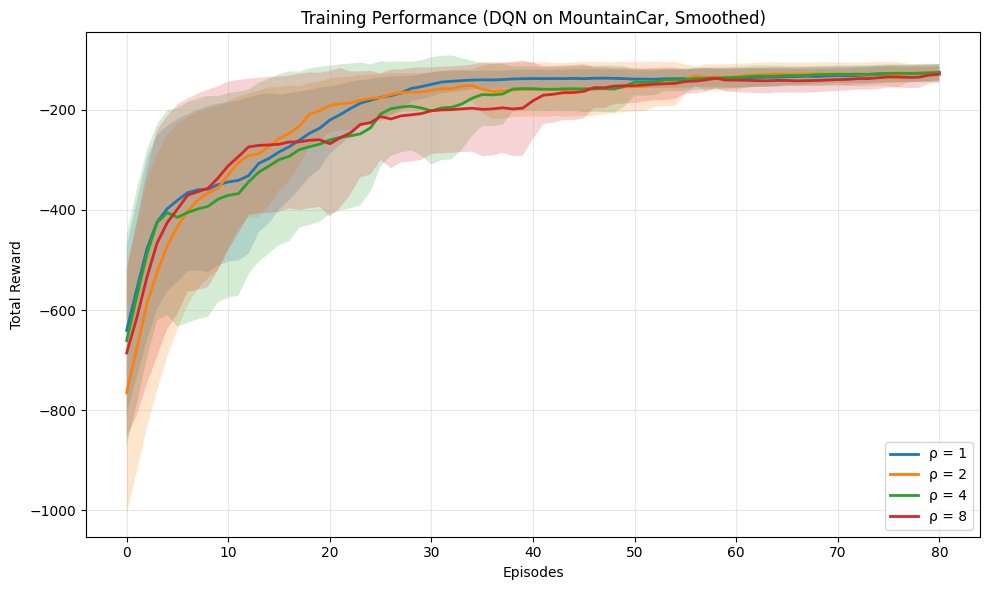

In [50]:
def moving_average(x, window=20):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 6))

label = "soumya_Q4_a"

for rho in sorted(data[label].keys()):
    all_rewards = np.array(data[label][rho])
    mean_rewards = np.mean(all_rewards, axis=0)
    std = np.std(all_rewards, axis=0)
    n = all_rewards.shape[0]
    ci = 1.96 * std / np.sqrt(n)

    smooth_mean = moving_average(mean_rewards, window=20)
    smooth_ci = moving_average(ci, window=20)

    x = np.arange(len(smooth_mean))

    plt.plot(x, smooth_mean, label=f"ρ = {rho}", linewidth=2)
    plt.fill_between(
        x,
        smooth_mean - smooth_ci,
        smooth_mean + smooth_ci,
        alpha=0.2
    )

plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Performance (DQN on MountainCar, Smoothed)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

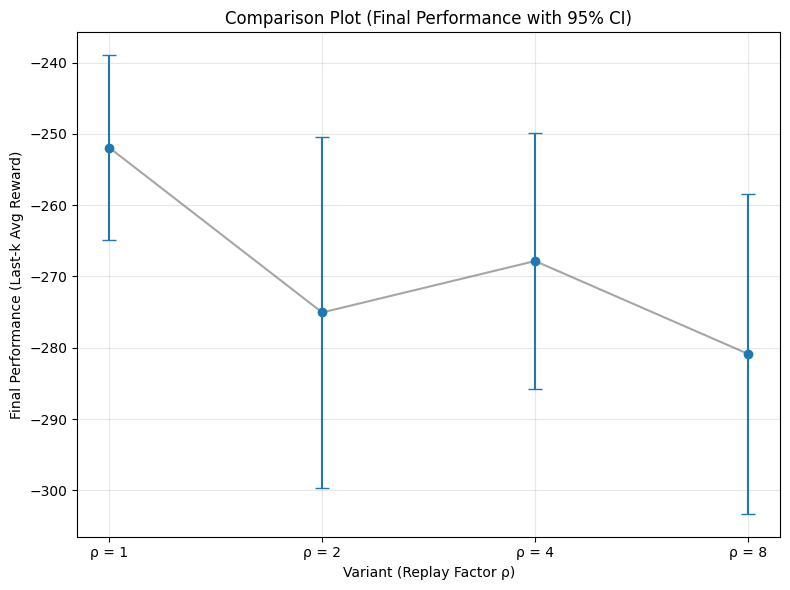

In [51]:
rhos = data[label].keys()

means = []
cis = []
k = 100   # last k episodes to average (tune: 50 / 100 / 200)

for rho in rhos:
    runs = data[label][rho] 
    final_scores = []

    for run in runs:
        final_scores.append(np.mean(run[-k:]))  # last-k average

    final_scores = np.array(final_scores)

    mean_val = np.mean(final_scores)
    std = np.std(final_scores)
    ci = 1.96 * std / np.sqrt(len(final_scores))

    means.append(mean_val)
    cis.append(ci)

plt.figure(figsize=(8,6))
x = np.arange(len(rhos))
plt.errorbar(
    x,
    means,
    yerr=cis,
    fmt='o',
    capsize=5
)
plt.plot(x, means, linestyle='-', color='gray', alpha=0.7)
plt.xticks(x, [f"ρ = {r}" for r in rhos])
plt.xlabel("Variant (Replay Factor ρ)")
plt.ylabel("Final Performance (Last-k Avg Reward)")
plt.title("Comparison Plot (Final Performance with 95% CI)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**4 B : DISTRIBUTION OF PERFORMANCE ACROSS DIFFERENT RHO VALUES**

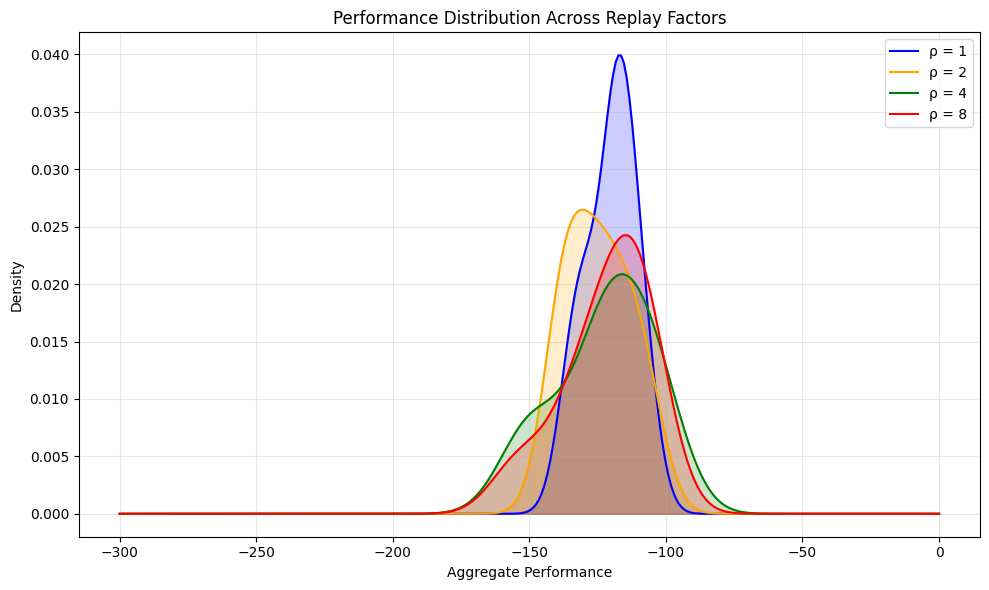

In [52]:
def compute_auc_per_run(data_rho):
    data_rho = np.array(data_rho)
    return np.mean(data_rho[:, -10:], axis=1)

label = "soumya_Q4_a"

auc_data = {}
for rho in data[label]:
    auc_data[rho] = compute_auc_per_run(data[label][rho])

plt.figure(figsize=(10,6))
colors = {1: 'blue', 2: 'orange', 4: 'green', 8: 'red'}

all_auc = np.concatenate(list(auc_data.values()))
x_vals = np.linspace(-300,0, 300)

for rho in auc_data:
    perf = auc_data[rho]
    kde = gaussian_kde(perf)

    plt.plot(x_vals, kde(x_vals), color=colors[rho], label=f"ρ = {rho}")
    plt.fill_between(x_vals, kde(x_vals), color=colors[rho], alpha=0.2)

plt.xlabel("Aggregate Performance")
plt.ylabel("Density")
plt.title("Performance Distribution Across Replay Factors")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**4 C : VARIABILITY IN PERFORMANCE (TOLERANCE INTERVALS)**

ρ = 1, k = 1.200
ρ = 2, k = 1.200
ρ = 4, k = 1.200
ρ = 8, k = 1.181


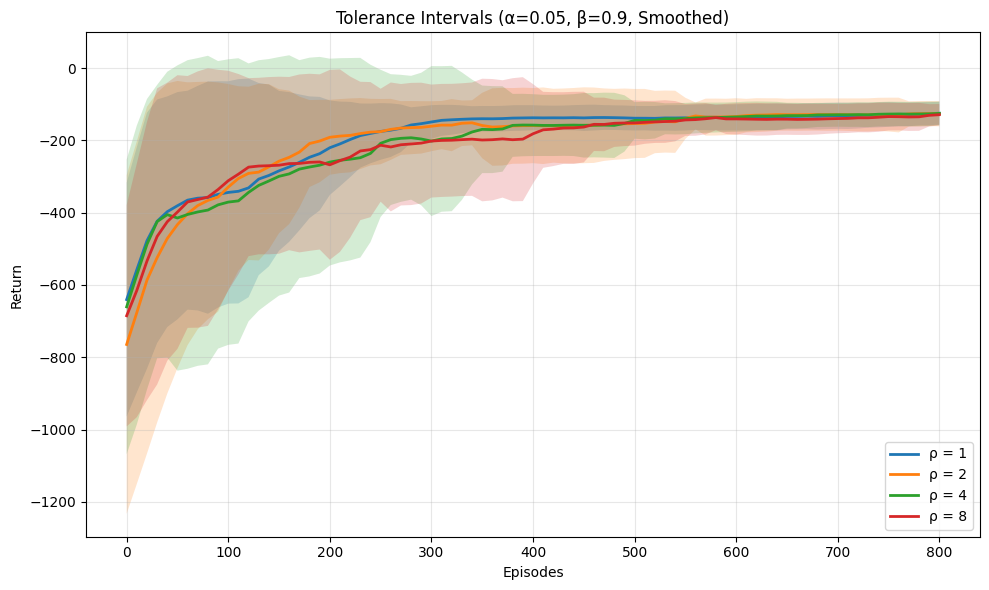

In [53]:
from scipy.stats import norm, chi2

label = "soumya_Q4_a"

def compute_k(n, alpha=0.05, beta=0.9):
    z = norm.ppf((1 + beta) / 2)          
    chi = chi2.ppf(1 - alpha, df=n - 1)   
    k = z * np.sqrt((n - 1) / chi)
    return k

def compute_tolerance_interval(data, alpha=0.05, beta=0.9):
    n = data.shape[0]
    k = compute_k(n, alpha, beta)

    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)

    lower = mean - k * std
    upper = mean + k * std

    return mean, lower, upper, k

plt.figure(figsize=(10,6))

window = 20 

for rho in data[label]:
    arr = np.array(data[label][rho])  
    mean, lower, upper, k = compute_tolerance_interval(arr)
    print(f"ρ = {rho}, k = {k:.3f}")  

    mean_s = np.convolve(mean, np.ones(window)/window, mode='valid')
    lower_s = np.convolve(lower, np.ones(window)/window, mode='valid')
    upper_s = np.convolve(upper, np.ones(window)/window, mode='valid')

    x = np.arange(len(mean_s)) * 10  

    plt.plot(x, mean_s, label=f"ρ = {rho}", linewidth=2)
    plt.fill_between(x, lower_s, upper_s, alpha=0.2)

plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("Tolerance Intervals (α=0.05, β=0.9, Smoothed)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Q5: BONUS (Prioritized Experience Replay)

In [57]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha  # How much prioritization to use (0 = uniform, 1 = full PER)
        self.buffer = []
        self.pos = 0
        self.priorities = np.zeros((capacity,), dtype=np.float32)

    def push(self, s, a, r, s_next, done):
        # New transitions get max priority so they are guaranteed to be sampled at least once
        max_prio = self.priorities.max() if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append((s, a, r, s_next, done))
        else:
            self.buffer[self.pos] = (s, a, r, s_next, done)
        
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == len(self.priorities):
            prios = self.priorities
        else:
            prios = self.priorities[:len(self.buffer)]

        # Calculate probabilities: P(i) = p_i^alpha / sum(p_i^alpha)
        probs = prios ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        # Importance Sampling (IS) weights to correct bias
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        weights = torch.tensor(weights, dtype=torch.float32).to(device)

        s, a, r, s_next, d = zip(*samples)
        return (
            torch.from_numpy(np.array(s)).float().to(device),
            torch.tensor(a, dtype=torch.long, device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.from_numpy(np.array(s_next)).float().to(device),
            torch.tensor(d, dtype=torch.float32, device=device),
            indices,
            weights
        )

    def update_priorities(self, indices, errors):
        for idx, error in zip(indices, errors):
            self.priorities[idx] = error + 1e-5  # Add small constant to avoid zero priority

    def __len__(self):
        return len(self.buffer)

In [ ]:
def train_per_dqn(seed=0):

    env = make_env(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LEARNING_RATE)
    replay_buffer = PrioritizedReplayBuffer(BUFFER_SIZE, ALPHA)

    beta_increment = (1.0 - BETA_START) / BETA_INC
    beta = BETA_START

    epsilon = EPS_START
    epsilon_decay = (EPS_START - EPS_END) / EPS_DECAY

    rewards = []
    total_steps = 0

    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        episode_reward = 0

        for _ in range(MAX_STEPS):
            total_steps += 1

            action = select_action(state, q_net, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            episode_reward += reward

            if len(replay_buffer) > BATCH_SIZE:
                for _ in range(RHO):
                    s, a, r, s_next, d, indices, weights = replay_buffer.sample(BATCH_SIZE, beta)
                    q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        max_next_q = target_net(s_next).max(1)[0]
                        target = r + GAMMA * max_next_q * (1 - d)

                    td_errors = torch.abs(q_values - target).detach().cpu().numpy()

                    loss = (weights * nn.MSELoss(reduction='none')(q_values, target)).mean()

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                    replay_buffer.update_priorities(indices, td_errors)
                beta = min(1.0, beta + beta_increment)
    
            if total_steps % TARGET_UPDATE == 0:
                target_net.load_state_dict(q_net.state_dict())

            epsilon = max(EPS_END, epsilon - epsilon_decay)
            
            if done:
                break

        rewards.append(episode_reward)

        if episode % 10 == 0:
            print(f"[Seed {seed}] Episode {episode}, Reward: {episode_reward}, "
                  f"Epsilon: {epsilon:.3f}, Beta: {beta:.3f}")

    env.close()

    print(f"[Seed {seed}] DONE")
    label = "name_Q5"
    save_result(seed, rewards, label)
    return rewards

In [ ]:
RHO = 1       # Change as required
for seed in range(15):
    _ = train_per_dqn(seed)